# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

In [4]:
exclude = ['id', 'target', 'delivery_start', 'market']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:152.08420	validation_1-rmse:62.91458
[100]	validation_0-rmse:114.64818	validation_1-rmse:53.16906
[200]	validation_0-rmse:91.61930	validation_1-rmse:48.35736
[300]	validation_0-rmse:76.99036	validation_1-rmse:46.36553
[400]	validation_0-rmse:66.93720	validation_1-rmse:45.94376
[500]	validation_0-rmse:59.96447	validation_1-rmse:46.00908
[560]	validation_0-rmse:56.73548	validation_1-rmse:46.30904


In [9]:
y_vals = xg.predict(test)

/home/matt/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [12:31:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(45.768973378684095)

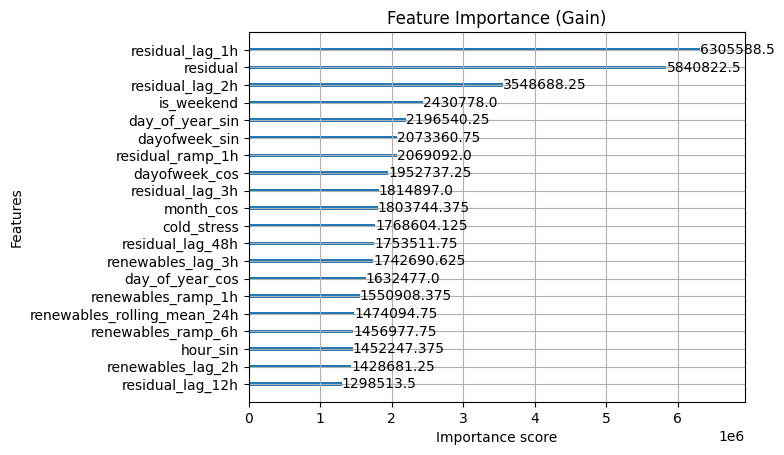

In [12]:
xg.stats()

In [13]:
ds2 = Dataset('test')

In [14]:
df_out = ds2.build_main()

In [15]:
y_out = xg.predict(df_out)

In [16]:
df_out['target'] = y_out

In [17]:
df_out.head()

,id,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,residual_lag_6h,residual_lag_12h,residual_lag_24h,residual_lag_48h,residual_rolling_mean_6h,residual_rolling_mean_24h,residual_ramp_1h,residual_ramp_3h,residual_ramp_6h,target
0,133627,0.0,0.0,0.0,100.0,14.0,44.0,100.0,0.0,16600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182.866943
1,133635,0.0,0.0,0.0,100.0,100.0,100.0,88.0,0.0,13800.0,...,NaN,NaN,NaN,NaN,51527.274200,51527.274200,-1463.3271,NaN,NaN,125.620331
2,133643,0.0,0.0,0.0,100.0,70.0,100.0,100.0,0.0,19700.0,...,NaN,NaN,NaN,NaN,50795.610650,50795.610650,-984.5816,NaN,NaN,175.879791
3,133651,0.0,0.0,0.0,99.0,13.0,99.0,94.0,0.0,16200.0,...,NaN,NaN,NaN,NaN,50223.528933,50223.528933,-489.7085,-2937.6172,NaN,175.187469
4,133659,0.0,0.0,0.0,96.0,0.0,96.0,79.0,0.0,14500.0,...,NaN,NaN,NaN,NaN,49815.060950,49815.060950,-121.4928,-1595.7829,NaN,179.704834


In [18]:
from utils import Submission

In [19]:
submit = Submission(df_out)

In [20]:
submit.process()

,id,target
0,133627,182.866943
2183,133629,77.259537
4366,133630,81.807373
10915,133631,75.290054
6549,133633,71.592712
...,...,...
4365,146774,44.309624
6548,146775,33.324314
13097,146776,33.958157
8731,146777,35.115559


In [21]:
submit.validate()

✅ Validation passed!


In [22]:
submit.dump()